In [1]:
# Cell 0.1: Cài đặt thư viện cần thiết (nếu chưa có)
!pip install vnstock keras-tuner tensorflow scikit-learn matplotlib pandas numpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.6/119.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 15.8 MB/s eta 0:00:00


In [ ]:
# Cell 0.2: Import các thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
from vnstock import Vnstock  # Thư viện lấy dữ liệu chứng khoán Việt Nam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Cấu hình hiển thị
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid') # Chọn style cho plot
pd.options.display.float_format = '{:,.2f}'.format # Định dạng số float

In [ ]:
# Cell 0.3: Các tham số cấu hình
STOCK_SYMBOL = 'HAG'
SOURCE = 'VCI' # Nguồn dữ liệu (vd: 'SSI', 'VCI', 'TCBS')
START_DATE = '2020-01-01' # Bắt đầu lấy dữ liệu từ ngày này (có thể lấy dài hơn để có đủ dữ liệu cho features)
END_DATE = '2025-04-30'   # Kết thúc lấy dữ liệu (có thể dùng datetime.today().strftime('%Y-%m-%d'))
VAL_DATE_START = '2024-01-01' # Ngày bắt đầu của tập validation
TEST_DATE_START = '2025-04-10' # Ngày bắt đầu của tập test

SEQUENCE_LENGTH = 60     # Độ dài chuỗi input cho LSTM (số ngày nhìn lại)
FEATURES = ['close', 'open', 'high', 'low', 'volume',
            'MA5', 'MA20', 'RSI', 'MACD', 'Signal_Line',
            'Price_Change', 'Volatility'] # Các features sử dụng

# Tham số mô hình LSTM
LSTM_UNITS = 128
DROPOUT_RATE = 0.2
LEARNING_RATE = 0.00001
EPOCHS = 100
BATCH_SIZE = 32
EARLY_STOPPING_PATIENCE = 15

MODEL_FILENAME = 'lstm_stock_model_vhc.h5'

In [ ]:
# Cell 1.1: Thu thập dữ liệu lịch sử giá cổ phiếu
print(f"Đang tải dữ liệu cổ phiếu {STOCK_SYMBOL} từ {START_DATE} đến {END_DATE}...")
try:
    stock_data_loader = Vnstock().stock(symbol=STOCK_SYMBOL, source=SOURCE)
    df_raw = stock_data_loader.quote.history(start=START_DATE, end=END_DATE, interval='1D')
    print("Tải dữ liệu thành công!")
    print(f"Số dòng dữ liệu gốc: {len(df_raw)}")
    display(df_raw.head())
    display(df_raw.tail())
except Exception as e:
    print(f"Lỗi khi tải dữ liệu: {e}")
    # Có thể thêm xử lý lỗi khác ở đây, ví dụ: thử nguồn khác hoặc dừng lại
    df_raw = pd.DataFrame() # Tạo dataframe rỗng nếu lỗi

Đang tải dữ liệu cổ phiếu HAG từ 2020-01-01 đến 2025-04-30...
Tải dữ liệu thành công!
Số dòng dữ liệu gốc: 1328


,time,open,high,low,close,volume
0,2020-01-02,3.96,4.05,3.96,4.05,1101390
1,2020-01-03,4.07,4.19,4.05,4.15,3756690
2,2020-01-06,4.15,4.15,4.03,4.09,1454140
3,2020-01-07,4.02,4.11,4.02,4.11,1432510
4,2020-01-08,4.06,4.08,3.91,3.91,2566730


,time,open,high,low,close,volume
1323,2025-04-23,12.15,12.15,11.95,12.00,3748800
1324,2025-04-24,12.00,12.60,11.95,12.25,6758900
1325,2025-04-25,12.30,12.60,12.20,12.45,8448500
1326,2025-04-28,12.40,13.30,12.30,13.30,28110600
1327,2025-04-29,13.40,13.65,13.10,13.10,7890200


In [ ]:
# Cell 1.2: Kiểm tra dữ liệu ban đầu
if not df_raw.empty:
    print("\nThông tin dữ liệu (Info):")
    df_raw.info()

    print("\nThống kê mô tả (Describe):")
    display(df_raw.describe())

    print("\nKiểm tra giá trị thiếu (Missing Values):")
    print(df_raw.isnull().sum())
else:
    print("Không có dữ liệu để xử lý.")


Thông tin dữ liệu (Info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    1328 non-null   datetime64[ns]
 1   open    1328 non-null   float64       
 2   high    1328 non-null   float64       
 3   low     1328 non-null   float64       
 4   close   1328 non-null   float64       
 5   volume  1328 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 62.4 KB

Thống kê mô tả (Describe):


,time,open,high,low,close,volume
count,1328,"1,328.00","1,328.00","1,328.00","1,328.00","1,328.00"
mean,2022-08-30 20:14:27.469879552,8.62,8.80,8.44,8.60,"12,131,819.24"
min,2020-01-02 00:00:00,2.45,2.63,2.40,2.55,"244,300.00"
25%,2021-05-05 18:00:00,5.20,5.29,5.10,5.20,"4,934,722.25"
50%,2022-08-29 12:00:00,8.61,8.80,8.40,8.60,"9,181,600.00"
75%,2023-12-25 06:00:00,11.90,12.15,11.70,11.90,"16,264,557.50"
max,2025-04-29 00:00:00,15.95,16.20,15.00,15.65,"62,236,100.00"
std,NaN,3.39,3.47,3.31,3.38,"9,910,526.27"



Kiểm tra giá trị thiếu (Missing Values):
time      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [ ]:
# Cell 1.3: Làm sạch và chuẩn hóa dữ liệu cơ bản
if not df_raw.empty:
    # Chọn các cột cần thiết và tạo bản sao để tránh SettingWithCopyWarning
    df = df_raw[['time', 'open', 'high', 'low', 'close', 'volume']].copy()

    # Chuyển cột 'time' sang định dạng datetime và đặt làm index
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)

    # Sắp xếp lại theo thời gian (quan trọng cho time series)
    df.sort_index(inplace=True)

    # Xử lý missing values (nếu có - thường ít gặp với OHLCV từ nguồn tốt)
    # Kiểm tra lại sau khi chọn cột
    if df.isnull().sum().sum() > 0:
        print(f"\nPhát hiện {df.isnull().sum().sum()} giá trị thiếu. Sử dụng phương pháp 'forward fill'...")
        df.fillna(method='ffill', inplace=True)
        # Kiểm tra lại sau khi fill
        if df.isnull().sum().sum() == 0:
            print("Đã xử lý xong giá trị thiếu.")
        else:
             print("Vẫn còn giá trị thiếu sau khi fill. Cần kiểm tra lại.")
    else:
        print("\nKhông tìm thấy giá trị thiếu trong các cột đã chọn.")

    # Đảm bảo kiểu dữ liệu số cho các cột giá và khối lượng
    for col in ['open', 'high', 'low', 'close', 'volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce') # Chuyển thành số, lỗi thành NaN

    # Kiểm tra lại NaN sau khi chuyển đổi kiểu dữ liệu
    if df.isnull().sum().sum() > 0:
        print(f"\nPhát hiện {df.isnull().sum().sum()} giá trị không hợp lệ sau khi chuyển đổi kiểu dữ liệu. Sử dụng 'forward fill'...")
        df.fillna(method='ffill', inplace=True)
        df.fillna(method='bfill', inplace=True) # Fill ngược lại nếu giá trị đầu tiên là NaN

    print("\nDữ liệu sau khi làm sạch cơ bản:")
    display(df.head())
    df.info()
else:
    print("Bỏ qua bước làm sạch do không có dữ liệu.")


Không tìm thấy giá trị thiếu trong các cột đã chọn.

Dữ liệu sau khi làm sạch cơ bản:


,open,high,low,close,volume
time,,,,,
2020-01-02,3.96,4.05,3.96,4.05,1101390
2020-01-03,4.07,4.19,4.05,4.15,3756690
2020-01-06,4.15,4.15,4.03,4.09,1454140
2020-01-07,4.02,4.11,4.02,4.11,1432510
2020-01-08,4.06,4.08,3.91,3.91,2566730


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1328 entries, 2020-01-02 to 2025-04-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    1328 non-null   float64
 1   high    1328 non-null   float64
 2   low     1328 non-null   float64
 3   close   1328 non-null   float64
 4   volume  1328 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 62.2 KB


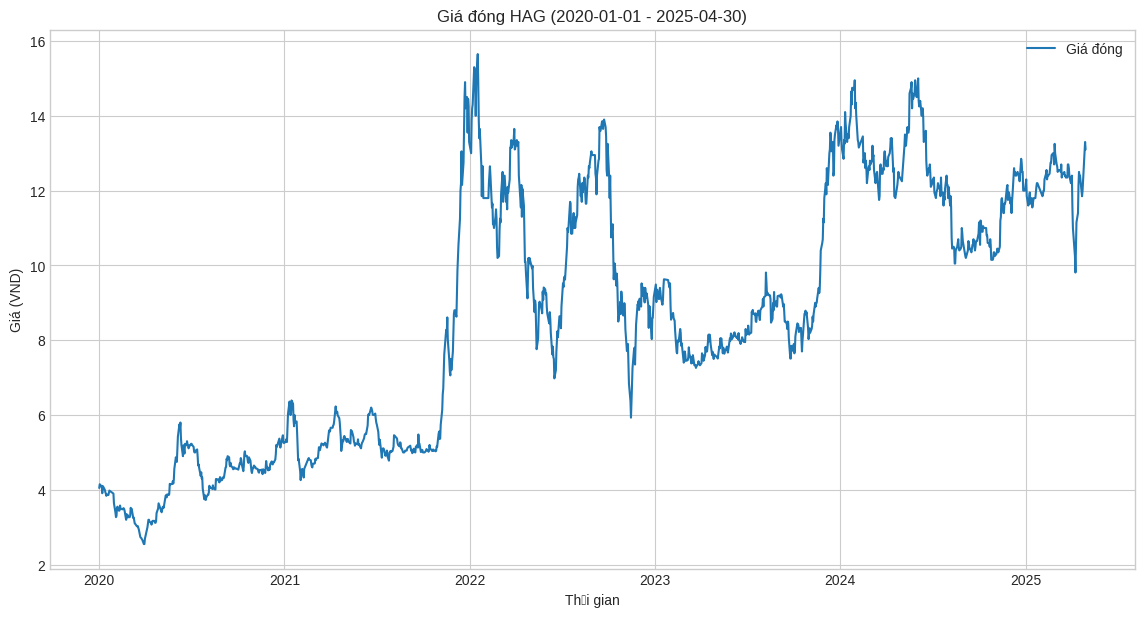

In [ ]:
# Cell 1.4: Trực quan hóa dữ liệu giá đóng cửa ban đầu
if not df.empty:
    plt.figure(figsize=(14, 7))
    plt.plot(df.index, df['close'], label='Giá đóng')
    plt.title(f'Giá đóng {STOCK_SYMBOL} ({START_DATE} - {END_DATE})')
    plt.xlabel('Thời gian')
    plt.ylabel('Giá (VND)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Không có dữ liệu để vẽ biểu đồ.")

In [ ]:
# Cell 1.5: Feature Engineering - Tạo các chỉ báo kỹ thuật

if not df.empty:
    print("\nĐang tạo các chỉ báo kỹ thuật...")
    # 1. Moving Averages (MA)
    df['MA5'] = df['close'].rolling(window=5).mean()
    df['MA20'] = df['close'].rolling(window=20).mean()

    # 2. Relative Strength Index (RSI)
    def calculate_rsi(data, window=14):
        delta = data.diff()
        gain = delta.where(delta > 0, 0).fillna(0)
        loss = -delta.where(delta < 0, 0).fillna(0)

        avg_gain = gain.rolling(window=window, min_periods=1).mean()
        avg_loss = loss.rolling(window=window, min_periods=1).mean()

        # Sử dụng rolling mean thay vì EWM cho RSI chuẩn
        # avg_gain = gain.ewm(com=window-1, adjust=False).mean()
        # avg_loss = loss.ewm(com=window-1, adjust=False).mean()


        rs = avg_gain / avg_loss
        rsi = 100 - (100 / (1 + rs))
        # Xử lý trường hợp avg_loss = 0 (RSI = 100)
        rsi = rsi.replace([np.inf, -np.inf], 100)
        # Xử lý trường hợp ban đầu là NaN nếu avg_loss và avg_gain cùng là 0
        rsi = rsi.fillna(50) # Giá trị trung tính ban đầu
        return rsi

    df['RSI'] = calculate_rsi(df['close'])

    # 3. Moving Average Convergence Divergence (MACD)
    def calculate_macd(data, fast=12, slow=26, signal=9):
        exp1 = data.ewm(span=fast, adjust=False).mean()
        exp2 = data.ewm(span=slow, adjust=False).mean()
        macd = exp1 - exp2
        signal_line = macd.ewm(span=signal, adjust=False).mean()
        return macd, signal_line

    df['MACD'], df['Signal_Line'] = calculate_macd(df['close'])

    # 4. Phần trăm thay đổi giá đóng cửa so với ngày trước
    df['Price_Change'] = df['close'].pct_change()

    # 5. Volatility - Độ biến động (Standard Deviation) của giá đóng cửa trong N ngày
    df['Volatility'] = df['close'].rolling(window=5).std()

    # Xóa các dòng có giá trị NaN được tạo ra bởi rolling/diff functions
    initial_rows = len(df)
    df.dropna(inplace=True)
    removed_rows = initial_rows - len(df)
    print(f"Đã xóa {removed_rows} dòng chứa NaN sau khi tạo features.")

    print("\nDữ liệu sau khi thêm features:")
    display(df.head())
    display(df.tail())
else:
    print("Bỏ qua Feature Engineering do không có dữ liệu.")


Đang tạo các chỉ báo kỹ thuật...
Đã xóa 19 dòng chứa NaN sau khi tạo features.

Dữ liệu sau khi thêm features:


,open,high,low,close,volume,MA5,MA20,RSI,MACD,Signal_Line,Price_Change,Volatility
time,,,,,,,,,,,,
2020-02-05,3.27,3.40,3.17,3.30,1285410,3.50,3.87,16.10,-0.16,-0.08,0.01,0.27
2020-02-06,3.30,3.53,3.30,3.53,3102020,3.43,3.84,30.22,-0.16,-0.10,0.07,0.16
2020-02-07,3.59,3.65,3.53,3.55,1286950,3.41,3.81,33.08,-0.15,-0.11,0.01,0.13
2020-02-10,3.50,3.55,3.43,3.44,791000,3.42,3.78,31.88,-0.16,-0.12,-0.03,0.13
2020-02-11,3.44,3.47,3.43,3.45,781430,3.45,3.74,33.33,-0.16,-0.13,0.00,0.10


,open,high,low,close,volume,MA5,MA20,RSI,MACD,Signal_Line,Price_Change,Volatility
time,,,,,,,,,,,,
2025-04-23,12.15,12.15,11.95,12.00,3748800,12.13,11.78,46.71,-0.06,-0.16,0.01,0.25
2025-04-24,12.00,12.60,11.95,12.25,6758900,12.10,11.75,56.39,-0.02,-0.13,0.02,0.22
2025-04-25,12.30,12.60,12.20,12.45,8448500,12.11,11.75,64.13,0.02,-0.10,0.02,0.24
2025-04-28,12.40,13.30,12.30,13.30,28110600,12.37,11.79,79.16,0.12,-0.06,0.07,0.57
2025-04-29,13.40,13.65,13.10,13.10,7890200,12.62,11.84,82.97,0.18,-0.01,-0.02,0.56


In [ ]:
# Cell 1.6: Chuẩn hóa dữ liệu (Scaling)
if not df.empty:
    print("\nChuẩn hóa dữ liệu sử dụng MinMaxScaler...")
    # Chọn các features sẽ sử dụng cho mô hình
    data_to_scale = df[FEATURES].copy()

    # Khởi tạo scaler
    scaler = MinMaxScaler(feature_range=(0, 1))

    # Fit và transform dữ liệu
    scaled_data = scaler.fit_transform(data_to_scale)

    # Tạo dataframe từ dữ liệu đã chuẩn hóa để dễ xem (không bắt buộc)
    scaled_df = pd.DataFrame(scaled_data, columns=FEATURES, index=data_to_scale.index)

    print("Dữ liệu sau khi chuẩn hóa (5 dòng đầu):")
    display(scaled_df.head())

    # Lưu scaler để sử dụng sau này khi giải mã dự đoán
    # (Trong Colab, biến scaler vẫn tồn tại, nhưng nếu chạy script riêng thì cần lưu)
    # import joblib
    # joblib.dump(scaler, 'minmax_scaler_vhc.gz')
else:
    print("Bỏ qua Scaling do không có dữ liệu.")


Chuẩn hóa dữ liệu sử dụng MinMaxScaler...
Dữ liệu sau khi chuẩn hóa (5 dòng đầu):


,close,open,high,low,volume,MA5,MA20,RSI,MACD,Signal_Line,Price_Change,Volatility
time,,,,,,,,,,,,
2020-02-05,0.06,0.06,0.06,0.06,0.02,0.07,0.08,0.15,0.33,0.35,0.57,0.23
2020-02-06,0.07,0.06,0.07,0.07,0.05,0.06,0.08,0.30,0.33,0.34,1.00,0.13
2020-02-07,0.08,0.08,0.08,0.09,0.02,0.06,0.08,0.33,0.33,0.34,0.54,0.10
2020-02-10,0.07,0.08,0.07,0.08,0.01,0.06,0.08,0.32,0.33,0.33,0.28,0.11
2020-02-11,0.07,0.07,0.06,0.08,0.01,0.07,0.07,0.33,0.33,0.33,0.52,0.08


In [ ]:
# Cell 1.7: Tạo chuỗi dữ liệu (Sequences) cho LSTM
if 'scaled_data' in locals() and scaled_data.shape[0] > SEQUENCE_LENGTH:
    # Hàm tạo sequences
    def create_sequences(data, seq_length):
        X, y = [], []
        for i in range(len(data) - seq_length):
            # Lấy seq_length điểm dữ liệu làm input (X)
            X.append(data[i : i + seq_length])
            # Lấy giá đóng cửa (cột 0) của điểm dữ liệu ngay sau chuỗi làm output (y)
            y.append(data[i + seq_length, 0])
        return np.array(X), np.array(y)

    print(f"\nTạo sequences với độ dài {SEQUENCE_LENGTH} ngày...")
    X, y = create_sequences(scaled_data, SEQUENCE_LENGTH)

    print(f"Kích thước dữ liệu X (sequences): {X.shape}") # (số lượng sequence, độ dài sequence, số features)
    print(f"Kích thước dữ liệu y (targets): {y.shape}") # (số lượng sequence,)
else:
    print("Không đủ dữ liệu để tạo sequences hoặc dữ liệu chưa được chuẩn hóa.")


Tạo sequences với độ dài 60 ngày...
Kích thước dữ liệu X (sequences): (1249, 60, 12)
Kích thước dữ liệu y (targets): (1249,)


In [ ]:
# Cell 1.8: Phân chia tập Train, Validation, Test theo thời gian

if 'X' in locals() and 'y' in locals():
    # Xác định index để chia dựa trên ngày đã định nghĩa trong cấu hình
    # Cần lấy index tương ứng trong mảng X, y (đã bị cắt đi SEQUENCE_LENGTH phần tử đầu)
    # Lấy index của df gốc (sau khi dropna)
    df_indices = df.index

    try:
        val_split_idx = df_indices.searchsorted(VAL_DATE_START) - SEQUENCE_LENGTH
        test_split_idx = df_indices.searchsorted(TEST_DATE_START) - SEQUENCE_LENGTH

        # Điều chỉnh index nếu âm (do sequence_length lớn hoặc ngày bắt đầu quá sớm)
        val_split_idx = max(0, val_split_idx)
        test_split_idx = max(val_split_idx, test_split_idx) # Đảm bảo test_idx >= val_idx

        # Kiểm tra xem các index có hợp lệ không
        if test_split_idx >= len(X):
             print("Cảnh báo: Ngày bắt đầu test quá muộn, không đủ dữ liệu cho tập test.")
             # Điều chỉnh lại, ví dụ chia theo tỷ lệ nếu ngày không hoạt động
             test_split_idx = len(X) # Không có test set
             if val_split_idx >= len(X):
                 val_split_idx = int(len(X) * 0.85) # Fallback: 85% train
             test_split_idx = int(len(X) * 0.95) # Fallback: 10% val, 5% test
             print(f"Sử dụng phân chia tỷ lệ dự phòng: Train={val_split_idx}, Val={test_split_idx-val_split_idx}, Test={len(X)-test_split_idx}")

        elif val_split_idx >= test_split_idx:
             print("Cảnh báo: Ngày bắt đầu validation trùng hoặc sau ngày bắt đầu test.")
             # Điều chỉnh lại, ví dụ chia theo tỷ lệ
             val_split_idx = int(len(X) * 0.7) # Fallback: 70% train
             test_split_idx = int(len(X) * 0.85) # Fallback: 15% val, 15% test
             print(f"Sử dụng phân chia tỷ lệ dự phòng: Train={val_split_idx}, Val={test_split_idx-val_split_idx}, Test={len(X)-test_split_idx}")


        # Thực hiện chia
        X_train, y_train = X[:val_split_idx], y[:val_split_idx]
        X_val, y_val = X[val_split_idx:test_split_idx], y[val_split_idx:test_split_idx]
        X_test, y_test = X[test_split_idx:], y[test_split_idx:]

        # Lấy index thời gian tương ứng cho từng tập để trực quan hóa sau này
        train_dates = df_indices[SEQUENCE_LENGTH : val_split_idx + SEQUENCE_LENGTH]
        val_dates = df_indices[val_split_idx + SEQUENCE_LENGTH : test_split_idx + SEQUENCE_LENGTH]
        test_dates = df_indices[test_split_idx + SEQUENCE_LENGTH :]


        print("\nPhân chia dữ liệu hoàn tất:")
        print(f"Kích thước tập huấn luyện (Train): X={X_train.shape}, y={y_train.shape}. Ngày: {train_dates.min().date()} - {train_dates.max().date()}")
        print(f"Kích thước tập validation (Val):  X={X_val.shape}, y={y_val.shape}. Ngày: {val_dates.min().date()} - {val_dates.max().date()}")
        print(f"Kích thước tập kiểm tra (Test):   X={X_test.shape}, y={y_test.shape}. Ngày: {test_dates.min().date()} - {test_dates.max().date()}")

    except KeyError as e:
        print(f"Lỗi: Không tìm thấy ngày '{e}' trong index. Có thể ngày đó là cuối tuần/ngày lễ hoặc ngoài phạm vi dữ liệu.")
        print("Hãy kiểm tra lại các biến VAL_DATE_START, TEST_DATE_START và phạm vi dữ liệu.")
        # Có thể thêm fallback chia theo tỷ lệ ở đây
        train_size = int(len(X) * 0.7)
        val_size = int(len(X) * 0.15)
        X_train, y_train = X[:train_size], y[:train_size]
        X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
        X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]
        print(f"\nSử dụng phân chia theo tỷ lệ dự phòng: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")
        # Lấy dates tương ứng với chia tỷ lệ
        train_dates = df_indices[SEQUENCE_LENGTH : train_size + SEQUENCE_LENGTH]
        val_dates = df_indices[train_size + SEQUENCE_LENGTH : train_size + val_size + SEQUENCE_LENGTH]
        test_dates = df_indices[train_size + val_size + SEQUENCE_LENGTH :]


else:
    print("Bỏ qua việc chia dữ liệu do thiếu dữ liệu sequences.")


Phân chia dữ liệu hoàn tất:
Kích thước tập huấn luyện (Train): X=(921, 60, 12), y=(921,). Ngày: 2020-05-04 - 2023-12-29
Kích thước tập validation (Val):  X=(314, 60, 12), y=(314,). Ngày: 2024-01-02 - 2025-04-09
Kích thước tập kiểm tra (Test):   X=(14, 60, 12), y=(14,). Ngày: 2025-04-10 - 2025-04-29


In [ ]:
# Cell 2.1: Xây dựng kiến trúc mô hình LSTM
def build_model(input_shape, lstm_units=50, dropout_rate=0.2):
    """Xây dựng mô hình Sequential LSTM."""
    model = Sequential()

    # Lớp LSTM thứ nhất
    # input_shape=(sequence_length, num_features)
    # return_sequences=True vì lớp LSTM tiếp theo cần output dạng chuỗi
    model.add(LSTM(units=lstm_units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout_rate)) # Giảm overfitting

    # Lớp LSTM thứ hai
    # return_sequences=False vì lớp Dense tiếp theo chỉ cần output cuối cùng
    model.add(LSTM(units=lstm_units, return_sequences=False))
    model.add(Dropout(dropout_rate))

    # Lớp Fully Connected (Dense) để đưa ra dự đoán cuối cùng
    # units=1 vì ta dự đoán một giá trị (giá đóng cửa)
    model.add(Dense(units=1))

    return model

# Kiểm tra xem có dữ liệu train không
if 'X_train' in locals() and X_train.shape[0] > 0 and X_train.shape[1] > 0:
    # Xác định input shape từ dữ liệu huấn luyện
    input_shape = (X_train.shape[1], X_train.shape[2]) # (sequence_length, num_features)

    # Khởi tạo mô hình
    model = build_model(input_shape, lstm_units=LSTM_UNITS, dropout_rate=DROPOUT_RATE)

    # Compile mô hình: định nghĩa optimizer, loss function
    optimizer = Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=optimizer, loss='mean_squared_error') # MSE phù hợp cho bài toán hồi quy

    # Hiển thị cấu trúc mô hình
    print("Cấu trúc mô hình LSTM:")
    model.summary()
else:
    print("Không thể xây dựng mô hình do thiếu dữ liệu huấn luyện (X_train).")

Cấu trúc mô hình LSTM:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        72,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,905 (796.50 KB)

 Trainable params: 203,905 (796.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 2.2: Huấn luyện mô hình
if 'model' in locals() and 'X_train' in locals() and 'y_train' in locals() and 'X_val' in locals() and 'y_val' in locals():
    print("\nBắt đầu huấn luyện mô hình...")

    # Callback để dừng sớm nếu validation loss không cải thiện
    early_stopping = EarlyStopping(
        monitor='val_loss',       # Theo dõi loss trên tập validation
        patience=EARLY_STOPPING_PATIENCE,        # Số epochs chờ trước khi dừng nếu không cải thiện
        restore_best_weights=True # Khôi phục trọng số của epoch tốt nhất
    )

    # Huấn luyện mô hình
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val), # Dữ liệu để đánh giá sau mỗi epoch
        callbacks=[early_stopping],      # Sử dụng early stopping
        verbose=1                        # Hiển thị progress bar
    )

    print("\nHuấn luyện hoàn tất!")

    # Đánh giá nhanh trên tập validation
    val_loss = model.evaluate(X_val, y_val, verbose=0)
    print(f"Validation Loss (MSE) của mô hình tốt nhất: {val_loss:.6f}")

else:
    print("Bỏ qua huấn luyện do thiếu mô hình hoặc dữ liệu.")


Bắt đầu huấn luyện mô hình...
Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.1683 - val_loss: 0.3173
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1046 - val_loss: 0.1817
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0493 - val_loss: 0.0962
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0251 - val_loss: 0.0467
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0158 - val_loss: 0.0256
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0105 - val_loss: 0.0181
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0109 - val_loss: 0.0162
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0094 - val_loss: 0.0147
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0111 - val_loss: 0.0127
Epoch 10/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0092 - val_loss: 0.0117
Epoch 11/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0101 - val_loss: 0.0113
Epoch 12/100
29/29 ━━

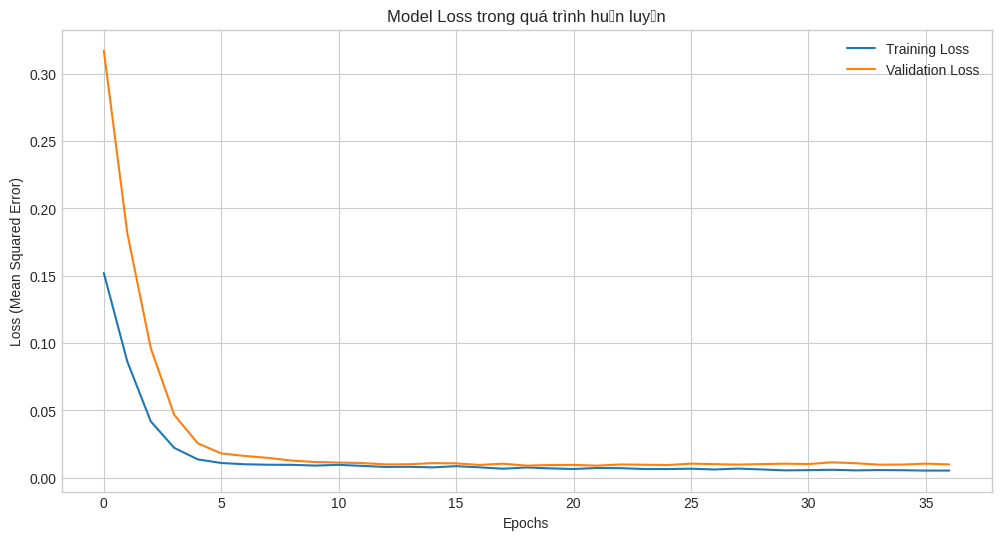

In [ ]:
# Cell 2.3: Vẽ đồ thị Loss trong quá trình huấn luyện
if 'history' in locals():
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss trong quá trình huấn luyện')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Mean Squared Error)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Không có lịch sử huấn luyện để vẽ đồ thị.")

In [ ]:
# Cell 2.4: Lưu mô hình đã huấn luyện
if 'model' in locals() and 'history' in locals():
    model.save(MODEL_FILENAME)
    print(f"\nMô hình đã được lưu vào file: {MODEL_FILENAME}")
else:
    print("Không có mô hình để lưu.")


Mô hình đã được lưu vào file: lstm_stock_model_vhc.h5


In [ ]:
# Cell 3.1: Tải lại mô hình (nếu cần, ví dụ sau khi restart kernel) và thực hiện dự đoán
# Nếu model vẫn còn trong bộ nhớ, có thể bỏ qua bước load
try:
    model = load_model(MODEL_FILENAME)
    print(f"Đã tải lại mô hình từ {MODEL_FILENAME}")
except Exception as e:
    print(f"Không thể tải lại mô hình từ file. Sử dụng mô hình hiện tại trong bộ nhớ (nếu có). Lỗi: {e}")

if 'model' in locals() and 'X_test' in locals() and X_test.shape[0] > 0:
    print("\nThực hiện dự đoán trên tập kiểm tra (Test set)...")
    y_pred_scaled = model.predict(X_test)

    # y_pred_scaled hiện là output đã chuẩn hóa (scale 0-1)
    # Cần giải mã (inverse transform) để có giá trị thực tế

    # Tạo một mảng tạm thời có cùng số cột như lúc scale ban đầu
    # Điền giá trị dự đoán (đã scale) vào cột 'close' (giả sử là cột 0)
    dummy_array = np.zeros((len(y_pred_scaled), len(FEATURES)))
    dummy_array[:, 0] = y_pred_scaled.flatten()

    # Sử dụng scaler đã fit trước đó để inverse transform
    y_pred_actual = scaler.inverse_transform(dummy_array)[:, 0]

    # Tương tự, giải mã y_test (target thực tế đã scale)
    dummy_array_test = np.zeros((len(y_test), len(FEATURES)))
    dummy_array_test[:, 0] = y_test.flatten()
    y_test_actual = scaler.inverse_transform(dummy_array_test)[:, 0]

    print("Đã giải mã giá trị dự đoán và giá trị thực tế về thang đo gốc.")
    print(f"Số lượng dự đoán: {len(y_pred_actual)}")

    # Tạo DataFrame kết quả để dễ so sánh
    results_df = pd.DataFrame({
        'Date': test_dates,
        'Actual Close': y_test_actual,
        'Predicted Close': y_pred_actual
    })
    results_df.set_index('Date', inplace=True)
    print("\nKết quả dự đoán và giá thực tế trên tập Test:")
    display(results_df.head())

else:
    print("Không thể thực hiện dự đoán do thiếu mô hình hoặc dữ liệu Test.")

Đã tải lại mô hình từ lstm_stock_model_vhc.h5

Thực hiện dự đoán trên tập kiểm tra (Test set)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
Đã giải mã giá trị dự đoán và giá trị thực tế về thang đo gốc.
Số lượng dự đoán: 14

Kết quả dự đoán và giá thực tế trên tập Test:


,Actual Close,Predicted Close
Date,,
2025-04-10,10.45,10.94
2025-04-11,11.15,10.88
2025-04-14,11.40,10.84
2025-04-15,12.15,10.80
2025-04-16,12.50,10.81


In [ ]:
# Cell 3.2: Đánh giá độ chính xác dự đoán
if 'y_test_actual' in locals() and 'y_pred_actual' in locals():
    print("\nĐánh giá độ chính xác dự đoán:")
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    r2 = r2_score(y_test_actual, y_pred_actual)
    # MAPE - Mean Absolute Percentage Error
    mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

    print(f"Mean Absolute Error (MAE):      {mae:,.2f} VND")
    print(f"Root Mean Squared Error (RMSE): {rmse:,.2f} VND")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
    print(f"R-squared (R²):                 {r2:.4f}")

    # Lưu các metrics này lại
    evaluation_metrics = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}
else:
    print("Không thể đánh giá độ chính xác do thiếu dữ liệu dự đoán hoặc thực tế.")


Đánh giá độ chính xác dự đoán:
Mean Absolute Error (MAE):      1.31 VND
Root Mean Squared Error (RMSE): 1.44 VND
Mean Absolute Percentage Error (MAPE): 10.63%
R-squared (R²):                 -3.0711


In [ ]:
# Cell 3.3: Định nghĩa Chiến lược Giao dịch Đơn giản và Hàm Backtesting

def simple_trading_strategy(actual_prices, predicted_prices):
    """
    Chiến lược:
    - Nếu giá dự đoán cho ngày mai (predicted_prices[i]) > giá thực tế hôm nay (actual_prices[i]),
      thì giữ vị thế Mua (1) cho ngày mai.
    - Ngược lại, giữ vị thế Bán hoặc không giữ (-1 hoặc 0). Chọn -1 để mô phỏng bán khống hoặc đóng vị thế mua.
    Trả về: Danh sách các vị thế (signals) cho ngày tiếp theo.
    """
    signals = []
    if len(actual_prices) != len(predicted_prices):
        print("Lỗi: Độ dài actual_prices và predicted_prices không khớp trong simple_trading_strategy")
        # Cắt bớt phần dư thừa để thử khớp
        min_len = min(len(actual_prices), len(predicted_prices))
        actual_prices = actual_prices[:min_len]
        predicted_prices = predicted_prices[:min_len]
        # return [] # Hoặc trả về rỗng

    for i in range(len(predicted_prices)):
         # Signal cho ngày i+1 dựa trên dự đoán tại i và giá thực tại i
        if predicted_prices[i] > actual_prices[i]:
            signals.append(1)  # Dự đoán tăng -> Mua/Giữ cho ngày mai
        else:
            signals.append(-1) # Dự đoán giảm/không tăng -> Bán/Không giữ cho ngày mai
    return signals

def run_backtest(actual_prices, signals, initial_capital=100000000, commission_rate=0.0015):
    """
    Thực hiện backtest dựa trên tín hiệu giao dịch.
    Args:
        actual_prices (np.array): Mảng giá đóng cửa thực tế trong giai đoạn test.
        signals (list): Danh sách tín hiệu (1: Mua/Giữ, -1: Bán/Không giữ) cho ngày tiếp theo.
                       signals[i] là tín hiệu áp dụng cho giao dịch *giữa* ngày i và i+1.
        initial_capital (float): Vốn ban đầu.
        commission_rate (float): Tỷ lệ phí giao dịch mỗi chiều.
    Returns:
        pd.DataFrame: DataFrame chứa lịch sử lợi nhuận, vốn tích lũy.
        dict: Dictionary chứa các chỉ số hiệu suất.
    """
    if len(signals) != len(actual_prices) -1:
        # print(f"Cảnh báo backtest: len(signals)={len(signals)} khác len(actual_prices)-1={len(actual_prices)-1}. Điều chỉnh signals.")
        # Điều chỉnh signals để khớp với số lượng lợi nhuận có thể tính được
        signals = signals[:len(actual_prices)-1]


    capital = initial_capital
    positions = 0 # Số lượng cổ phiếu đang nắm giữ
    portfolio_values = [initial_capital] # Giá trị danh mục theo thời gian
    daily_returns = [] # Lợi nhuận % hàng ngày của chiến lược

    # Lặp qua các ngày giao dịch (từ ngày thứ 1 đến ngày cuối cùng -1)
    for i in range(len(signals)):
        current_price = actual_prices[i]
        next_day_price = actual_prices[i+1]
        signal = signals[i] # Tín hiệu cho hành động vào cuối ngày i / đầu ngày i+1

        # Tính lợi nhuận/thua lỗ từ vị thế nắm giữ *trong* ngày i+1
        # Dựa trên giá thay đổi từ cuối ngày i (current_price) đến cuối ngày i+1 (next_day_price)
        # và vị thế được quyết định bởi signal[i]

        # Tính % thay đổi giá ngày hôm sau
        price_change_pct = (next_day_price - current_price) / current_price

        # Lợi nhuận của ngày đến từ vị thế nắm giữ *trước đó* nhân với thay đổi giá
        # Vị thế của ngày i+1 được quyết định bởi signal[i]
        # Ta giả định signal = 1 là Long, signal = -1 là Short (hoặc Flat)
        # Lợi nhuận = signal * price_change_pct (bỏ qua phí và lãi suất vay margin cho đơn giản)
        # Lưu ý: signal[i] quyết định vị thế cho ngày i+1. Lợi nhuận này là của ngày i+1.
        daily_return = signal * price_change_pct
        daily_returns.append(daily_return)

        # Cập nhật giá trị danh mục (đơn giản hóa, chỉ theo % return)
        capital *= (1 + daily_return)
        portfolio_values.append(capital)

#         Lưu ý: Phần mô phỏng mua/bán với phí giao dịch phức tạp hơn và có thể thêm vào nếu cần
#         Ví dụ:
        # if signal == 1 and positions == 0: # Mua
        #     shares_to_buy = capital / current_price
        #     cost = shares_to_buy * current_price * (1 + commission_rate)
        #     capital -= cost
        #     positions = shares_to_buy
        # elif signal == -1 and positions > 0: # Bán
        #     revenue = positions * current_price * (1 - commission_rate)
        #     capital += revenue
        #     positions = 0
        # portfolio_values.append(capital + positions * current_price)


    # Tạo DataFrame kết quả backtest
    backtest_results = pd.DataFrame({
        'Date': actual_prices.index[1:], # Bắt đầu từ ngày thứ 2 vì return tính cho ngày đó
        'Portfolio Value': portfolio_values[1:],
        'Daily Return (%)': np.array(daily_returns) * 100
    })
    backtest_results.set_index('Date', inplace=True)

    # Tính toán các chỉ số hiệu suất
    if not backtest_results.empty and len(daily_returns) > 0:
        total_return = (backtest_results['Portfolio Value'].iloc[-1] / initial_capital - 1)
        num_days = len(daily_returns)
        # Giả sử 252 ngày giao dịch/năm
        annual_return = (1 + total_return) ** (252 / num_days) - 1 if num_days > 0 else 0

        daily_returns_np = np.array(daily_returns)
        # Bỏ qua các giá trị NaN hoặc Inf có thể xảy ra
        daily_returns_np = daily_returns_np[np.isfinite(daily_returns_np)]


        if len(daily_returns_np) > 0 and np.std(daily_returns_np) > 0:
             sharpe_ratio = np.mean(daily_returns_np) / np.std(daily_returns_np) * np.sqrt(252)
        else:
            sharpe_ratio = 0

        # Max Drawdown
        cumulative_returns = (1 + daily_returns_np).cumprod()
        peak = np.maximum.accumulate(cumulative_returns)
        drawdown = (cumulative_returns - peak) / peak
        max_drawdown = np.min(drawdown) if len(drawdown) > 0 else 0

    else:
        total_return = 0
        annual_return = 0
        sharpe_ratio = 0
        max_drawdown = 0

    performance_metrics = {
        'Total Return (%)': total_return * 100,
        'Annualized Return (%)': annual_return * 100,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown (%)': max_drawdown * 100,
        'Number of Trades/Signals': len(signals)
    }

    return backtest_results, performance_metrics

print("Đã định nghĩa hàm chiến lược giao dịch và hàm backtesting.")

Đã định nghĩa hàm chiến lược giao dịch và hàm backtesting.


In [ ]:
# Cell 3.4: Thực hiện Backtesting trên tập Test
if 'results_df' in locals() and not results_df.empty:
    print("\nThực hiện backtesting trên tập Test...")

    # Lấy giá thực tế và dự đoán từ results_df đã tạo trước đó
    actual_test_prices = results_df['Actual Close']
    predicted_test_prices = results_df['Predicted Close']

    # Tạo tín hiệu giao dịch
    # Lưu ý: Cần giá thực tế của ngày i để tạo tín hiệu cho ngày i+1
    # Do đó, actual_prices dùng để tạo signal sẽ kết thúc sớm hơn 1 ngày so với predicted_prices
    # Tuy nhiên, hàm simple_trading_strategy đã xử lý việc này bằng cách lặp đến len(predicted)
    # Cần đảm bảo cả hai series này có cùng index thời gian và độ dài phù hợp
    signals = simple_trading_strategy(actual_test_prices.values[:-1], predicted_test_prices.values[:-1])


    # Chạy backtest
    # actual_test_prices chứa toàn bộ giá trong giai đoạn test
    backtest_results_df, performance_metrics = run_backtest(actual_test_prices, signals)

    print("\nKết quả Backtesting:")
    display(backtest_results_df.head())
    display(backtest_results_df.tail())

    print("\nCác chỉ số hiệu suất của chiến lược LSTM:")
    performance_summary_lstm = pd.DataFrame([performance_metrics])
    display(performance_summary_lstm)

else:
    print("Không thể thực hiện backtesting do thiếu dữ liệu dự đoán hoặc thực tế trên tập Test.")


Thực hiện backtesting trên tập Test...

Kết quả Backtesting:


,Portfolio Value,Daily Return (%)
Date,,
2025-04-11,"106,698,564.59",6.70
2025-04-14,"104,306,220.10",-2.24
2025-04-15,"97,443,968.77",-6.58
2025-04-16,"94,636,940.87",-2.88
2025-04-17,"95,394,036.39",0.80


,Portfolio Value,Daily Return (%)
Date,,
2025-04-23,"98,440,101.58",-1.27
2025-04-24,"96,389,266.13",-2.08
2025-04-25,"94,815,563.83",-1.63
2025-04-28,"88,342,212.08",-6.83
2025-04-29,"89,670,666.40",1.50



Các chỉ số hiệu suất của chiến lược LSTM:


,Total Return (%),Annualized Return (%),Sharpe Ratio,Max Drawdown (%),Number of Trades/Signals
0,-10.33,-87.92,-3.45,-17.20,13


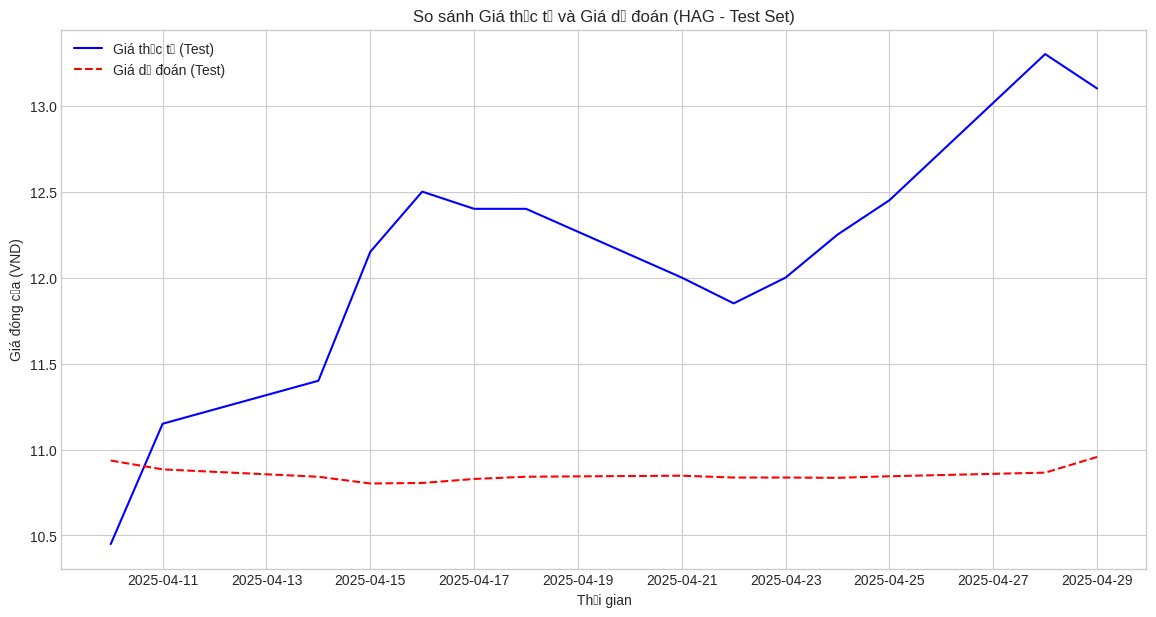

In [ ]:
# Cell 4.1: Trực quan hóa Kết quả Dự đoán vs Thực tế trên tập Test
if 'results_df' in locals() and not results_df.empty:
    plt.figure(figsize=(14, 7))
    plt.plot(results_df.index, results_df['Actual Close'], label='Giá thực tế (Test)', color='blue')
    plt.plot(results_df.index, results_df['Predicted Close'], label='Giá dự đoán (Test)', color='red', linestyle='--')
    plt.title(f'So sánh Giá thực tế và Giá dự đoán ({STOCK_SYMBOL} - Test Set)')
    plt.xlabel('Thời gian')
    plt.ylabel('Giá đóng cửa (VND)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Không có dữ liệu để vẽ biểu đồ so sánh dự đoán.")

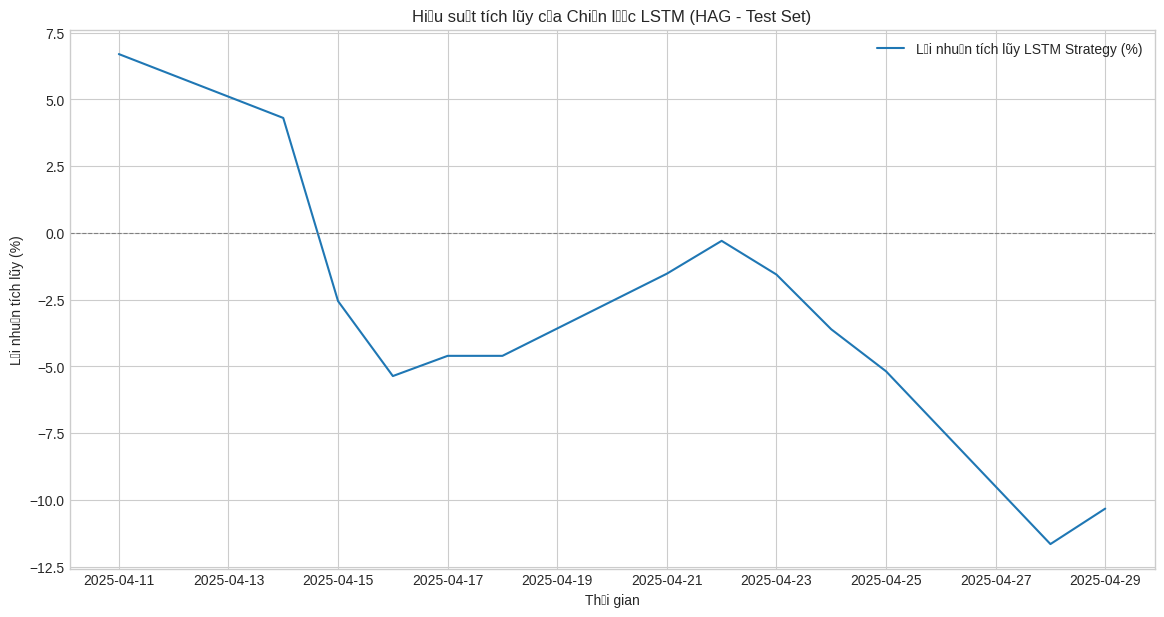

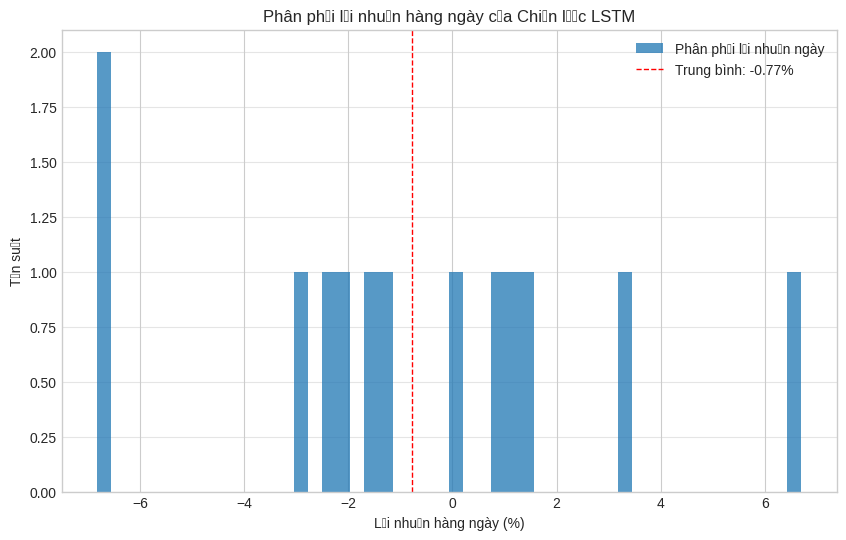

In [ ]:
# Cell 4.2: Trực quan hóa Hiệu suất Chiến lược Giao dịch (Lợi nhuận tích lũy)
if 'backtest_results_df' in locals() and not backtest_results_df.empty:
    # Tính lợi nhuận tích lũy từ lợi nhuận hàng ngày
    backtest_results_df['Cumulative Return (%)'] = (1 + backtest_results_df['Daily Return (%)'] / 100).cumprod() - 1
    backtest_results_df['Cumulative Return (%)'] *= 100 # Chuyển sang %

    plt.figure(figsize=(14, 7))
    plt.plot(backtest_results_df.index, backtest_results_df['Cumulative Return (%)'], label='Lợi nhuận tích lũy LSTM Strategy (%)')
    plt.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
    plt.title(f'Hiệu suất tích lũy của Chiến lược LSTM ({STOCK_SYMBOL} - Test Set)')
    plt.xlabel('Thời gian')
    plt.ylabel('Lợi nhuận tích lũy (%)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Vẽ biểu đồ phân phối lợi nhuận hàng ngày
    plt.figure(figsize=(10, 6))
    plt.hist(backtest_results_df['Daily Return (%)'].dropna(), bins=50, alpha=0.75, label='Phân phối lợi nhuận ngày')
    plt.axvline(backtest_results_df['Daily Return (%)'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Trung bình: {backtest_results_df["Daily Return (%)"].mean():.2f}%')
    plt.title('Phân phối lợi nhuận hàng ngày của Chiến lược LSTM')
    plt.xlabel('Lợi nhuận hàng ngày (%)')
    plt.ylabel('Tần suất')
    plt.legend()
    plt.grid(axis='y', alpha=0.5)
    plt.show()

else:
    print("Không có dữ liệu backtest để vẽ biểu đồ hiệu suất.")

In [ ]:
# Cell 4.3: Dự đoán giá cho ngày tiếp theo (Future Prediction)

def predict_next_day(model, df_full, scaler, sequence_length, features):
    """Dự đoán giá đóng cửa cho ngày giao dịch tiếp theo."""
    # Lấy sequence_length ngày dữ liệu cuối cùng từ dataframe đầy đủ (đã có features)
    last_sequence_data = df_full[features].values[-sequence_length:]

    if last_sequence_data.shape[0] < sequence_length:
        print(f"Lỗi: Không đủ dữ liệu ({last_sequence_data.shape[0]} ngày) để tạo sequence dự đoán (cần {sequence_length} ngày).")
        return None

    # Chuẩn hóa sequence này bằng scaler đã dùng
    last_sequence_scaled = scaler.transform(last_sequence_data)

    # Reshape thành đúng định dạng input cho LSTM: (1, sequence_length, num_features)
    X_next = np.array([last_sequence_scaled])

    # Dự đoán giá trị đã scale
    y_next_scaled = model.predict(X_next)

    # Giải mã giá trị dự đoán
    # Tạo mảng dummy và điền giá trị dự đoán vào cột 'close' (cột 0)
    dummy_pred = np.zeros((1, len(features)))
    dummy_pred[0, 0] = y_next_scaled[0, 0]

    # Inverse transform
    y_next_actual = scaler.inverse_transform(dummy_pred)[0, 0]

    return y_next_actual

# Kiểm tra xem các biến cần thiết có tồn tại không
if 'model' in locals() and 'df' in locals() and 'scaler' in locals() and 'FEATURES' in locals():
    print("\nDự đoán giá đóng cửa cho ngày giao dịch tiếp theo...")
    # Lấy ngày cuối cùng trong dữ liệu df
    last_data_date = df.index[-1]
    print(f"Dữ liệu cuối cùng dùng để dự đoán là của ngày: {last_data_date.date()}")

    # Thực hiện dự đoán
    next_day_predicted_price = predict_next_day(model, df, scaler, SEQUENCE_LENGTH, FEATURES)

    if next_day_predicted_price is not None:
        # Tìm ngày giao dịch tiếp theo (bỏ qua cuối tuần/ngày lễ - cách đơn giản là +1 ngày làm việc)
        # Lưu ý: Cách này không hoàn toàn chính xác nếu có ngày nghỉ lễ bất thường
        next_trading_day = pd.to_datetime(last_data_date) + pd.offsets.BDay(1)
        print(f"Dự đoán giá đóng cửa cho ngày {next_trading_day.date()}: {next_day_predicted_price:,.2f} VND")
    else:
        print("Không thể thực hiện dự đoán cho ngày tiếp theo.")

else:
    print("Bỏ qua dự đoán ngày tiếp theo do thiếu model, dữ liệu gốc (df), scaler hoặc danh sách features.")


Dự đoán giá đóng cửa cho ngày giao dịch tiếp theo...
Dữ liệu cuối cùng dùng để dự đoán là của ngày: 2025-04-29
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
Dự đoán giá đóng cửa cho ngày 2025-04-30: 11.05 VND
